In [1]:
!pip install --upgrade pip
!pip install mediapipe opencv-python scikit-learn tqdm --quiet


Defaulting to user installation because normal site-packages is not writeable
  Using cached pip-25.3-py3-none-any.whl.metadata (4.7 kB)
Using cached pip-25.3-py3-none-any.whl (1.8 MB)



[notice] A new release of pip is available: 25.2 -> 25.3
[notice] To update, run: C:\Python314\python.exe -m pip install --upgrade pip
ERROR: To modify pip, please run the following command:
C:\Python314\python.exe -m pip install --upgrade pip
ERROR: Could not find a version that satisfies the requirement mediapipe (from versions: none)

[notice] A new release of pip is available: 25.2 -> 25.3
[notice] To update, run: C:\Python314\python.exe -m pip install --upgrade pip
ERROR: No matching distribution found for mediapipe


In [2]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("ayuraj/asl-dataset")

print("Path to dataset files:", path)

Path to dataset files: C:\Users\ameya\.cache\kagglehub\datasets\ayuraj\asl-dataset\versions\1


In [3]:
import os

for label in sorted(os.listdir(path)):
    folder = os.path.join(path, label)
    if os.path.isdir(folder):
        print(label, "->", len(os.listdir(folder)), "directories")


asl_dataset -> 37 directories


In [4]:
dataset_path = "C:/Users/ameya/.cache/kagglehub/datasets/ayuraj/asl-dataset/versions/1/asl_dataset"

print("Dataset path:", dataset_path)
print("\nFolders inside dataset:")
for item in sorted(os.listdir(dataset_path)):
    print("  -", item)


Dataset path: C:/Users/ameya/.cache/kagglehub/datasets/ayuraj/asl-dataset/versions/1/asl_dataset

Folders inside dataset:
  - 0
  - 1
  - 2
  - 3
  - 4
  - 5
  - 6
  - 7
  - 8
  - 9
  - a
  - asl_dataset
  - b
  - c
  - d
  - e
  - f
  - g
  - h
  - i
  - j
  - k
  - l
  - m
  - n
  - o
  - p
  - q
  - r
  - s
  - t
  - u
  - v
  - w
  - x
  - y
  - z


In [7]:
RAW_DATASET_PATH = "C:/Users/ameya/.cache/kagglehub/datasets/ayuraj/asl-dataset/versions/1/asl_dataset/asl_dataset"

print("Dataset path:", RAW_DATASET_PATH)
print("\nFolders inside dataset:")
for item in sorted(os.listdir(RAW_DATASET_PATH)):
    print("  -", item)


Dataset path: C:/Users/ameya/.cache/kagglehub/datasets/ayuraj/asl-dataset/versions/1/asl_dataset/asl_dataset

Folders inside dataset:
  - 0
  - 1
  - 2
  - 3
  - 4
  - 5
  - 6
  - 7
  - 8
  - 9
  - a
  - b
  - c
  - d
  - e
  - f
  - g
  - h
  - i
  - j
  - k
  - l
  - m
  - n
  - o
  - p
  - q
  - r
  - s
  - t
  - u
  - v
  - w
  - x
  - y
  - z


In [8]:
print("\nImages per class:\n")
class_counts = {}

for label in sorted(os.listdir(dataset_path)):
    class_dir = os.path.join(dataset_path, label)
    if os.path.isdir(class_dir):
        count = len([f for f in os.listdir(class_dir) if f.lower().endswith((".jpg",".jpeg",".png"))])
        class_counts[label] = count
        print(f"{label}: {count} images")

print("\nTotal classes:", len(class_counts))
print("Total images:", sum(class_counts.values()))



Images per class:

0: 70 images
1: 70 images
2: 70 images
3: 70 images
4: 70 images
5: 70 images
6: 70 images
7: 70 images
8: 70 images
9: 70 images
a: 70 images
asl_dataset: 0 images
b: 70 images
c: 70 images
d: 70 images
e: 70 images
f: 70 images
g: 70 images
h: 70 images
i: 70 images
j: 70 images
k: 70 images
l: 70 images
m: 70 images
n: 70 images
o: 70 images
p: 70 images
q: 70 images
r: 70 images
s: 70 images
t: 65 images
u: 70 images
v: 70 images
w: 70 images
x: 70 images
y: 70 images
z: 70 images

Total classes: 37
Total images: 2515


Found 2515 images across 37 classes.


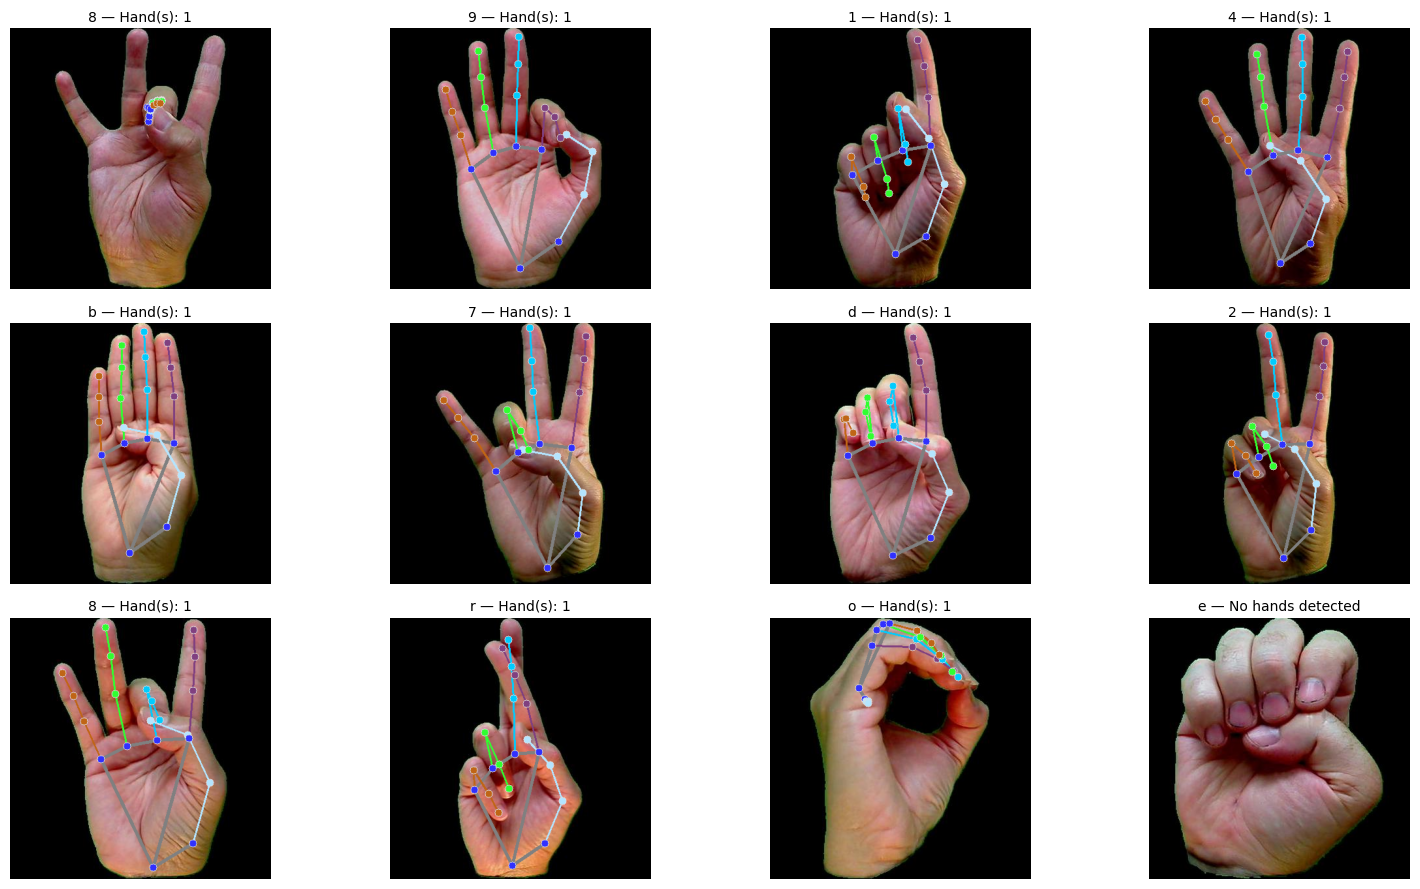

In [9]:
import random
import cv2
import mediapipe as mp
import matplotlib.pyplot as plt

all_image_paths = []
for label in sorted(os.listdir(dataset_path)):
    class_dir = os.path.join(dataset_path, label)
    if not os.path.isdir(class_dir):
        continue
    for fname in os.listdir(class_dir):
        if fname.lower().endswith((".png", ".jpg", ".jpeg")):
            all_image_paths.append((label, os.path.join(class_dir, fname)))

print("Found", len(all_image_paths), "images across", len(os.listdir(dataset_path)), "classes.")

sampled = random.sample(all_image_paths, min(12, len(all_image_paths)))   #Plotting images to see the dataset

# MediaPipe
mp_hands = mp.solutions.hands
mp_drawing = mp.solutions.drawing_utils
mp_styles = mp.solutions.drawing_styles

# Use context manager so resources are freed automatically
with mp_hands.Hands(static_image_mode=True, min_detection_confidence=0.25) as hands:
    plt.figure(figsize=(16, 9))
    cols = 4
    rows = (len(sampled) + cols - 1) // cols

    for idx, (label, img_path) in enumerate(sampled):
        img = cv2.imread(img_path)
        if img is None:
            print("Could not read", img_path)
            continue

        img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

        # run MediaPipe
        results = hands.process(img_rgb)

        # create a copy for drawing
        annotated = img_rgb.copy()
        if results.multi_hand_landmarks:
            for hand_landmarks in results.multi_hand_landmarks:
                mp_drawing.draw_landmarks(
                    annotated,
                    hand_landmarks,
                    mp_hands.HAND_CONNECTIONS,
                    mp_styles.get_default_hand_landmarks_style(),
                    mp_styles.get_default_hand_connections_style()
                )
            status = f"{label} — Hand(s): {len(results.multi_hand_landmarks)}"
        else:
            status = f"{label} — No hands detected"

        # plot
        plt_idx = idx + 1
        ax = plt.subplot(rows, cols, plt_idx)
        ax.imshow(annotated)
        ax.set_title(status, fontsize=10)
        ax.axis("off")

    plt.tight_layout()
    plt.show()

In [10]:
import os
import shutil
import math
import numpy as np
import cv2

classes = sorted([d for d in os.listdir(dataset_path) if os.path.isdir(os.path.join(dataset_path, d))])

# prepare report storage
report_rows = []
overall_total = 0
overall_detected = 0
overall_not_detected = 0
overall_unreadable = 0

# location for filtered (only images where hands detected)
FILTERED_DIR = "filtered_dataset"
os.makedirs(FILTERED_DIR, exist_ok=True)

# convenience: allowed image extensions
IMG_EXTS = (".png", ".jpg", ".jpeg", ".bmp")

# run MediaPipe Hands in a with-context so it frees resources afterward
with mp_hands.Hands(static_image_mode=True, min_detection_confidence=0.25) as hands:
    for cls in classes:
        class_dir = os.path.join(dataset_path, cls)
        # create corresponding filtered class folder
        filtered_cls_dir = os.path.join(FILTERED_DIR, cls)
        os.makedirs(filtered_cls_dir, exist_ok=True)

        # count metrics for this class
        total = 0
        detected = 0
        not_detected = 0
        unreadable = 0

        # list files (only common image extensions)
        files = sorted([f for f in os.listdir(class_dir) if f.lower().endswith(IMG_EXTS)])

        for fname in files:
            total += 1
            img_path = os.path.join(class_dir, fname)
            try:
                img = cv2.imread(img_path)
                if img is None:
                    unreadable += 1
                    continue

                # ensure BGR -> RGB for MediaPipe
                img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
                results = hands.process(img_rgb)

                if results.multi_hand_landmarks:
                    detected += 1

                    # Copy to filtered folder (avoid clobbering existing filenames)
                    dst_path = os.path.join(filtered_cls_dir, fname)
                    if os.path.exists(dst_path):
                        # if name conflict, add a small suffix
                        base, ext = os.path.splitext(fname)
                        count = 1
                        while True:
                            candidate = f"{base}_dup{count}{ext}"
                            dst_candidate = os.path.join(filtered_cls_dir, candidate)
                            if not os.path.exists(dst_candidate):
                                dst_path = dst_candidate
                                break
                            count += 1
                    try:
                        shutil.copy2(img_path, dst_path)
                    except Exception as e:
                        # Don't fail the loop on a single copy error; warn & continue
                        print(f"Warning: failed to copy {img_path} to {dst_path}: {e}")

                else:
                    not_detected += 1

            except Exception as e:
                # treat unexpected errors reading/processing the file as unreadable
                unreadable += 1

        # compute detection rate (consider only readable images)
        readable = total - unreadable
        detection_rate = (detected / readable * 100) if readable > 0 else float('nan')

        report_rows.append({
            "class": cls,
            "total_images": total,
            "unreadable_files": unreadable,
            "readable_images": readable,
            "images_with_hands": detected,
            "images_with_no_hands": not_detected,
            "detection_rate_pct": round(detection_rate, 2)
        })

        overall_total += total
        overall_detected += detected
        overall_not_detected += not_detected
        overall_unreadable += unreadable

# Overall summary
overall_readable = overall_total - overall_unreadable
overall_detection_rate = (overall_detected / overall_readable * 100) if overall_readable > 0 else float('nan')

# For a table-like report
print("\n" + "="*72)
print("CLASS-WISE HAND DETECTION REPORT")
print("="*72)
print(f"{'CLASS':>6} | {'TOTAL':>5} | {'READ':>5} | {'UNREAD':>6} | {'HANDS':>5} | {'NO_HAND':>7} | {'DETECT_%':>8}")
print("-"*72)
for r in report_rows:
    print(f"{r['class']:>6} | {r['total_images']:5d} | {r['readable_images']:5d} | {r['unreadable_files']:6d} | {r['images_with_hands']:5d} | {r['images_with_no_hands']:7d} | {str(r['detection_rate_pct']).rjust(8)}")
print("-"*72)
print(f"{'TOTAL':>6} | {overall_total:5d} | {overall_readable:5d} | {overall_unreadable:6d} | {overall_detected:5d} | {overall_not_detected:7d} | {round(overall_detection_rate,2)}")
print("="*72 + "\n")


CLASS-WISE HAND DETECTION REPORT
 CLASS | TOTAL |  READ | UNREAD | HANDS | NO_HAND | DETECT_%
------------------------------------------------------------------------
     0 |    70 |    70 |      0 |    42 |      28 |     60.0
     1 |    70 |    70 |      0 |    66 |       4 |    94.29
     2 |    70 |    70 |      0 |    60 |      10 |    85.71
     3 |    70 |    70 |      0 |    69 |       1 |    98.57
     4 |    70 |    70 |      0 |    70 |       0 |    100.0
     5 |    70 |    70 |      0 |    70 |       0 |    100.0
     6 |    70 |    70 |      0 |    59 |      11 |    84.29
     7 |    70 |    70 |      0 |    67 |       3 |    95.71
     8 |    70 |    70 |      0 |    64 |       6 |    91.43
     9 |    70 |    70 |      0 |    70 |       0 |    100.0
     a |    70 |    70 |      0 |    27 |      43 |    38.57
asl_dataset |     0 |     0 |      0 |     0 |       0 |      nan
     b |    70 |    70 |      0 |    67 |       3 |    95.71
     c |    70 |    70 |      0 | 

In [11]:
import numpy as np
import pickle
from tqdm import tqdm
from collections import Counter

FILTERED_DIR = "filtered_dataset"      # images where MP detected at least one hand
BALANCED_DIR = "balanced_dataset"      # after  to media augmentationan
DATA_PKL_PATH = "data.pickle"
MODEL_PKL_PATH = "ASL_Model.p"

# MediaPipe and processing settings
MIN_CONFIDENCE = 0.25
RANDOM_SEED = 42
random.seed(RANDOM_SEED)
np.random.seed(RANDOM_SEED)

In [12]:
import cv2

def random_augment(img_rgb):
    out = img_rgb.copy()
    h, w = out.shape[:2]

    # Flip horizontally 50% (hand signs might be mirrored - only apply if acceptable)
    if random.random() < 0.5:
        out = cv2.flip(out, 1)

    # Rotation
    angle = random.uniform(-20, 20)
    M = cv2.getRotationMatrix2D((w/2, h/2), angle, 1.0)
    out = cv2.warpAffine(out, M, (w, h), borderMode=cv2.BORDER_REPLICATE)

    # Scale (zoom)
    scale = random.uniform(0.9, 1.1)
    M = cv2.getRotationMatrix2D((w/2, h/2), 0, scale)
    out = cv2.warpAffine(out, M, (w, h), borderMode=cv2.BORDER_REPLICATE)

    # Brightness/contrast
    alpha = random.uniform(0.85, 1.15)
    beta = random.uniform(-15, 15)
    out = np.clip(out.astype(np.float32) * alpha + beta, 0, 255).astype(np.uint8)

    # Small translation
    tx = int(random.uniform(-0.03*w, 0.03*w))
    ty = int(random.uniform(-0.03*h, 0.03*h))
    M = np.float32([[1,0,tx],[0,1,ty]])
    out = cv2.warpAffine(out, M, (w, h), borderMode=cv2.BORDER_REPLICATE)

    return out




In [13]:
# Filter images: keep only those where MediaPipe detects at least one hand (strict)
os.makedirs(FILTERED_DIR, exist_ok=True)

mp_hands = mp.solutions.hands
mp_settings = dict(static_image_mode=True, min_detection_confidence=MIN_CONFIDENCE)

classes = sorted([d for d in os.listdir(RAW_DATASET_PATH) if os.path.isdir(os.path.join(RAW_DATASET_PATH, d))])
print("Classes found:", classes)

filtered_counts = {}
with mp_hands.Hands(**mp_settings) as hands:
    for cls in classes:
        src_dir = os.path.join(RAW_DATASET_PATH, cls)
        dst_dir = os.path.join(FILTERED_DIR, cls)
        os.makedirs(dst_dir, exist_ok=True)
        files = sorted([f for f in os.listdir(src_dir) if f.lower().endswith(('.png','.jpg','.jpeg','.bmp'))])
        kept = 0
        for fname in tqdm(files, desc=f"Filtering {cls}"):
            p = os.path.join(src_dir, fname)
            img = cv2.imread(p)
            if img is None:
                continue
            img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
            res = hands.process(img_rgb)
            if res.multi_hand_landmarks:
                # copy original file to filtered dataset
                dst = os.path.join(dst_dir, fname)
                shutil.copy(p, dst)
                kept += 1
        filtered_counts[cls] = kept

print("\nFiltered counts (images where MP detected a hand):")
for k in classes:
    print(f"{k}: {filtered_counts.get(k,0)}")


Classes found: ['0', '1', '2', '3', '4', '5', '6', '7', '8', '9', 'a', 'b', 'c', 'd', 'e', 'f', 'g', 'h', 'i', 'j', 'k', 'l', 'm', 'n', 'o', 'p', 'q', 'r', 's', 't', 'u', 'v', 'w', 'x', 'y', 'z']


Filtering 0:   0%|          | 0/70 [00:00<?, ?it/s]

Filtering z: 100%|██████████| 70/70 [00:01<00:00, 37.95it/s]


Filtered counts (images where MP detected a hand):
0: 42
1: 66
2: 60
3: 69
4: 70
5: 70
6: 59
7: 67
8: 64
9: 70
a: 27
b: 67
c: 49
d: 69
e: 38
f: 70
g: 64
h: 57
i: 59
j: 29
k: 70
l: 69
m: 17
n: 22
o: 36
p: 61
q: 24
r: 56
s: 17
t: 13
u: 65
v: 63
w: 65
x: 52
y: 45
z: 58


In [14]:
# Compute median target count for balancing
detected_counts = [filtered_counts[c] for c in classes]
print("Detected counts per class:", detected_counts)

median_target = int(np.median([c for c in detected_counts if c>0]))  # avoid zero classes
min_target = min([c for c in detected_counts if c>0])
max_target = max(detected_counts)

print(f"\nMin detected: {min_target}, Median detected: {median_target}, Max detected: {max_target}")
TARGET_PER_CLASS = median_target
print("Using TARGET_PER_CLASS =", TARGET_PER_CLASS)


Detected counts per class: [42, 66, 60, 69, 70, 70, 59, 67, 64, 70, 27, 67, 49, 69, 38, 70, 64, 57, 59, 29, 70, 69, 17, 22, 36, 61, 24, 56, 17, 13, 65, 63, 65, 52, 45, 58]

Min detected: 13, Median detected: 59, Max detected: 70
Using TARGET_PER_CLASS = 59


In [15]:
# Create balanced dataset by copying originals
os.makedirs(BALANCED_DIR, exist_ok=True)
mp_hands = mp.solutions.hands

# Augmentation only with the filtered images (which already have hands)
for cls in classes:
    src_cls = os.path.join(FILTERED_DIR, cls)
    dst_cls = os.path.join(BALANCED_DIR, cls)
    os.makedirs(dst_cls, exist_ok=True)

    # list existing (filtered) images
    imgs = sorted([f for f in os.listdir(src_cls) if f.lower().endswith(('.png','.jpg','.jpeg','.bmp'))])
    if len(imgs) == 0:
        print(f"Warning: class {cls} has zero filtered images. Skipping.")
        continue

    for fname in imgs:
        shutil.copy(os.path.join(src_cls, fname), os.path.join(dst_cls, fname))

    current = len(imgs)
    idx = 0

    # Augment until target
    while current < TARGET_PER_CLASS:
        src = os.path.join(src_cls, imgs[idx % len(imgs)])
        img = cv2.imread(src)
        if img is None:
            idx += 1
            continue
        img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        aug = random_augment(img_rgb)
        out_name = f"aug_{idx}_{os.path.basename(src)}"
        out_path = os.path.join(dst_cls, out_name)
        # save in BGR for cv2
        cv2.imwrite(out_path, cv2.cvtColor(aug, cv2.COLOR_RGB2BGR))
        current += 1
        idx += 1

print("Balanced dataset created at:", os.path.abspath(BALANCED_DIR))
# verification
for cls in classes:
    p = os.path.join(BALANCED_DIR, cls)
    c = len([f for f in os.listdir(p) if f.lower().endswith(('.png','.jpg','.jpeg','.bmp'))]) if os.path.isdir(p) else 0
    print(f"{cls}: {c}")


Balanced dataset created at: c:\Users\ameya\Downloads\balanced_dataset
0: 59
1: 66
2: 60
3: 69
4: 70
5: 70
6: 59
7: 67
8: 64
9: 70
a: 59
b: 67
c: 59
d: 69
e: 59
f: 70
g: 64
h: 59
i: 59
j: 59
k: 70
l: 69
m: 59
n: 59
o: 59
p: 61
q: 59
r: 59
s: 59
t: 59
u: 65
v: 63
w: 65
x: 59
y: 59
z: 59


In [16]:
# Extract landmarks (first detected hand) for each balanced image
mp_hands = mp.solutions.hands
dataset_feats = []
dataset_labels = []
class_list = []

def extract_features_from_landmarks(hand_landmarks):
    xs = [lm.x for lm in hand_landmarks.landmark]
    ys = [lm.y for lm in hand_landmarks.landmark]
    min_x = min(xs)
    min_y = min(ys)
    feats = []
    for i in range(len(hand_landmarks.landmark)):
        feats.append(hand_landmarks.landmark[i].x - min_x)
        feats.append(hand_landmarks.landmark[i].y - min_y)
    return feats

classes_balanced = sorted([d for d in os.listdir(BALANCED_DIR) if os.path.isdir(os.path.join(BALANCED_DIR, d))])
class_list = classes_balanced.copy()

with mp_hands.Hands(static_image_mode=True, min_detection_confidence=MIN_CONFIDENCE) as hands:
    for cls_idx, cls in enumerate(classes_balanced):
        cls_dir = os.path.join(BALANCED_DIR, cls)
        files = sorted([f for f in os.listdir(cls_dir) if f.lower().endswith(('.png','.jpg','.jpeg','.bmp'))])
        print(f"Extracting landmarks for class '{cls}' ({len(files)} images)...")
        for fname in tqdm(files, desc=f"Feat {cls}"):
            p = os.path.join(cls_dir, fname)
            img = cv2.imread(p)
            if img is None:
                continue
            img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
            res = hands.process(img_rgb)
            if not res.multi_hand_landmarks:
                # This should be rare (we filtered earlier) — skip if so
                continue
            lm = res.multi_hand_landmarks[0]
            feats = extract_features_from_landmarks(lm)
            dataset_feats.append(feats)
            dataset_labels.append(cls_idx)

dataset_feats = np.array(dataset_feats, dtype=np.float32)
dataset_labels = np.array(dataset_labels, dtype=np.int64)
print("Features shape:", dataset_feats.shape)
print("Labels shape:", dataset_labels.shape)

# Save to pickle
with open(DATA_PKL_PATH, "wb") as f:
    pickle.dump({'data': dataset_feats, 'labels': dataset_labels, 'classes': class_list}, f)

print("Saved features+labels to:", DATA_PKL_PATH)


Extracting landmarks for class '0' (59 images)...


Feat 0: 100%|██████████| 59/59 [00:03<00:00, 17.56it/s]


Extracting landmarks for class '1' (66 images)...


Feat 1: 100%|██████████| 66/66 [00:04<00:00, 13.92it/s]


Extracting landmarks for class '2' (60 images)...


...

Extracting landmarks for class 'y' (59 images)...


Feat y: 100%|██████████| 59/59 [00:03<00:00, 17.52it/s]


Extracting landmarks for class 'z' (59 images)...


Feat z: 100%|██████████| 59/59 [00:03<00:00, 17.95it/s]


Features shape: (2182, 42)
Labels shape: (2182,)
Saved features+labels to: data.pickle


In [17]:
# Train RandomForest classifier (landmark features)
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

with open(DATA_PKL_PATH, "rb") as f:
    dd = pickle.load(f)
X = dd['data']
y = dd['labels']
classes = dd['classes']
print("Number of classes:", len(classes))

# Train/test split (stratified)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=RANDOM_SEED, stratify=y)

clf = RandomForestClassifier(n_estimators=200, random_state=RANDOM_SEED, n_jobs=-1)
print("Training RandomForest...")
clf.fit(X_train, y_train)

# Evaluate
y_pred = clf.predict(X_test)
acc = accuracy_score(y_test, y_pred)
print(f"Test accuracy: {acc*100:.2f}%\n")
print("Classification report:")
print(classification_report(y_test, y_pred, target_names=classes, digits=4))

# Saving model with class mapping
model_dict = {'model': clf, 'classes': classes}
with open(MODEL_PKL_PATH, "wb") as f:
    pickle.dump(model_dict, f)
print("Saved trained model to:", MODEL_PKL_PATH)


Number of classes: 36
Training RandomForest...
Test accuracy: 92.45%

Classification report:
              precision    recall  f1-score   support

           0     0.7273    0.7273    0.7273        11
           1     1.0000    1.0000    1.0000        13
           2     0.8462    0.9167    0.8800        12
           3     0.9333    1.0000    0.9655        14
           4     0.8571    0.8571    0.8571        14
           5     0.8571    0.8571    0.8571        14
           6     1.0000    0.9167    0.9565        12
           7     1.0000    1.0000    1.0000        13
           8     1.0000    0.8462    0.9167        13
           9     1.0000    1.0000    1.0000        14
           a     0.9091    0.9091    0.9091        11
           b     0.9286    1.0000    0.9630        13
           c     0.9231    1.0000    0.9600        12
           d     1.0000    1.0000    1.0000        14
           e     0.8462    1.0000    0.9167        11
           f     1.0000    1.0000    1.000

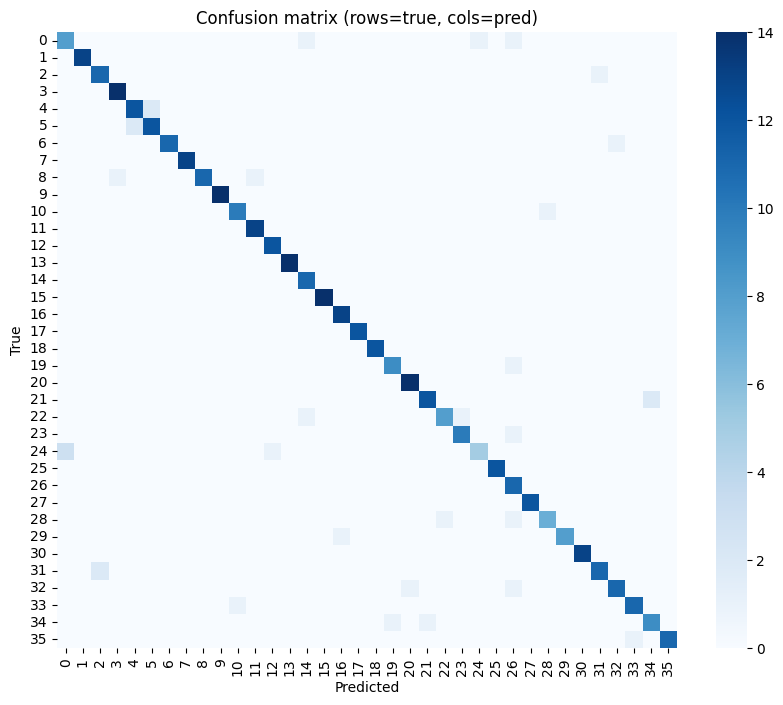

0: 54 samples
1: 66 samples
2: 60 samples
3: 69 samples
4: 70 samples
5: 70 samples
6: 59 samples
7: 67 samples
8: 64 samples
9: 70 samples
a: 53 samples
b: 67 samples
c: 59 samples
d: 69 samples
e: 56 samples
f: 70 samples
g: 64 samples
h: 59 samples
i: 59 samples
j: 53 samples
k: 70 samples
l: 69 samples
m: 51 samples
n: 53 samples
o: 48 samples
p: 61 samples
q: 55 samples
r: 59 samples
s: 46 samples
t: 45 samples
u: 65 samples
v: 63 samples
w: 65 samples
x: 59 samples
y: 56 samples
z: 59 samples


In [18]:
# EVALUATION: Confusion matrix & class counts
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

# compute confusion matrix on X_test
y_pred = clf.predict(X_test)
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(10,8))
sns.heatmap(cm, annot=False, fmt='d', cmap='Blues')
plt.title("Confusion matrix (rows=true, cols=pred)")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.show()

# class counts
unique, counts = np.unique(dataset_labels, return_counts=True)
for idx, cnt in zip(unique, counts):
    print(f"{classes[idx]}: {cnt} samples")


In [22]:
import cv2
import numpy as np
import mediapipe as mp
import pickle
import random
import string
import sys

MODEL_PKL_PATH = "ASL_Model.p"     # your saved model file
MIN_DETECTION_CONF = 0.25
MIN_TRACKING_CONF = 0.5
CAM_INDEX = 0                      # 0 = default webcam
RANDOM_SEED = 42

DEFAULT_LABELS = list("0123456789" + string.ascii_lowercase)

random.seed(RANDOM_SEED)
np.random.seed(RANDOM_SEED)


def load_model_and_labels(path):
    """
    Tries to load:
      - either a plain model object (with .predict / .predict_proba)
      - or a dict containing 'model', and optionally 'label_encoder' or 'labels'.
    Returns: (model, labels)
    'labels' can be:
      - list/array of class names (in index order)
      - None, if not available
    """
    with open(path, "rb") as f:
        obj = pickle.load(f)

    if hasattr(obj, "predict"):
        model = obj
        labels = None
        print("[INFO] Loaded classifier directly from pickle.")
        return model, labels

    if isinstance(obj, dict):
        print("[INFO] Loaded dict from pickle. Keys:", list(obj.keys()))

        model = obj.get("model") or obj.get("clf") or obj.get("classifier")
        if model is None:
            print("[ERROR] Could not find model inside dict. "
                  "Expected key 'model' (or 'clf' / 'classifier').")
            sys.exit(1)

        labels = obj.get("labels") or obj.get("label_encoder") or obj.get("le")

        if hasattr(labels, "classes_"):
            labels = list(labels.classes_)
            print("[INFO] Found label encoder, using classes_ as labels.")

        return model, labels

    sys.exit(1)


model, loaded_labels = load_model_and_labels(MODEL_PKL_PATH)

# Choose which label list to use
if loaded_labels is not None:
    LABELS = list(loaded_labels)
    print("[INFO] Using labels from pickle:", LABELS)
else:
    LABELS = DEFAULT_LABELS
    print("[INFO] Using default labels:", LABELS)

mp_hands = mp.solutions.hands
mp_drawing = mp.solutions.drawing_utils

hands = mp_hands.Hands(
    static_image_mode=False,       # stream mode
    max_num_hands=1,
    min_detection_confidence=MIN_DETECTION_CONF,
    min_tracking_confidence=MIN_TRACKING_CONF
)


# 3) -------- FEATURE EXTRACTION --------

def build_feature_vector(landmarks):
    """
    Convert MediaPipe's 21 landmarks into a 42-dim feature vector:
    [x1', y1', x2', y2', ..., x21', y21']

    Where x' = x - min_x, y' = y - min_y

    This matches the very common training setup used in ASL/hand-gesture projects.
    """
    xs = [lm.x for lm in landmarks]
    ys = [lm.y for lm in landmarks]

    min_x = min(xs)
    min_y = min(ys)

    data = []
    for lm in landmarks:
        data.append(lm.x - min_x)
        data.append(lm.y - min_y)

    return np.array(data, dtype=np.float32).reshape(1, -1)

cap = cv2.VideoCapture(CAM_INDEX)

if not cap.isOpened():
    print(" Could not open webcam.")
    sys.exit(1)

print(" Webcam opened. Press 'q' to quit.")

while True:
    ret, frame = cap.read()
    if not ret:
        print("Failed to grab frame.")
        break

    # Mirror image for natural selfie view
    frame = cv2.flip(frame, 1)

    # BGR -> RGB for MediaPipe
    img_rgb = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
    results = hands.process(img_rgb)

    pred_text = "No hand detected"

    if results.multi_hand_landmarks:
        # Use first hand only
        hand_landmarks = results.multi_hand_landmarks[0]

        # Draw landmarks
        mp_drawing.draw_landmarks(
            frame,
            hand_landmarks,
            mp_hands.HAND_CONNECTIONS
        )

        # Build feature vector
        X = build_feature_vector(hand_landmarks.landmark)

        # Predict
        try:
            # Try probability-based prediction
            if hasattr(model, "predict_proba"):
                proba = model.predict_proba(X)[0]
                idx = int(np.argmax(proba))
                conf = float(proba[idx])
            else:
                raise AttributeError
        except AttributeError:
            # Fallback: only predict()
            pred = model.predict(X)
            idx = int(pred[0])  # may be int-like or label
            conf = None

        # Map index/label to readable class
        label = None

        # If idx is already a label (e.g. 'a', 'b', '3', etc.)
        if not isinstance(idx, (int, np.integer)):
            label = str(idx)
        else:
            # idx is numeric; use LABELS array if within range
            if 0 <= idx < len(LABELS):
                label = str(LABELS[idx])
            else:
                label = str(idx)

        # Build text
        if conf is not None:
            pred_text = f"Pred: {label} ({conf*100:.1f}%)"
        else:
            pred_text = f"Pred: {label}"

    # Put prediction text on the frame
    cv2.putText(frame, pred_text, (10, 40),
                cv2.FONT_HERSHEY_SIMPLEX, 1.0, (0, 255, 0), 2)

    # Show window
    cv2.imshow("ASL Realtime Prediction", frame)

    # Quit on 'q'
    if cv2.waitKey(1) & 0xFF == ord('q'):
        break

cap.release()
cv2.destroyAllWindows()
hands.close()


[INFO] Loaded dict from pickle. Keys: ['model', 'classes']
[INFO] Using default labels: ['0', '1', '2', '3', '4', '5', '6', '7', '8', '9', 'a', 'b', 'c', 'd', 'e', 'f', 'g', 'h', 'i', 'j', 'k', 'l', 'm', 'n', 'o', 'p', 'q', 'r', 's', 't', 'u', 'v', 'w', 'x', 'y', 'z']
 Webcam opened. Press 'q' to quit.
